In [12]:
'''Project.1. Data Cleaning & EDA: Retail Sales Analysis 
Project Overview 
This foundational project teaches essential data preparation and exploratory data analysis 
(EDA) techniques using real retail sales data 
Learning Objectives 
 Import and inspect datasets using Pandas 
 Detect and handle missing values and duplicates 
 Identify and treat outliers using statistical methods 
 Generate summary statistics and data distributions 
 Create visualizations to uncover patterns and relationships 
 Document data quality issues and transformation steps 
Dataset Information 
Data Link: Kaggle Retail Sales Dataset  
Expected Columns: 
 Transaction ID / Date 
 Product Category 
 Sales Amount / Quantity 
 Customer Demographics (age, segment) 
Step-by-Step Guidance 
Phase 1: Data Loading & Inspection  
Phase 2: Data Cleaning  
Phase 3: Outlier Detection & Treatment  
Phase 4: Summary Statistics & Visualization 
Deliverables 
 Jupyter notebook with cleaned dataset 
 Data quality report (missing %, outliers %, transformations applied) 
 4-6 visualizations showing key patterns 
 Final clean CSV file 
Tools & Libraries 
Python, Pandas, NumPy, Matplotlib, Seaborn '''

'Project.1. Data Cleaning & EDA: Retail Sales Analysis \nProject Overview \nThis foundational project teaches essential data preparation and exploratory data analysis \n(EDA) techniques using real retail sales data \nLearning Objectives \n\uf0b7 Import and inspect datasets using Pandas \n\uf0b7 Detect and handle missing values and duplicates \n\uf0b7 Identify and treat outliers using statistical methods \n\uf0b7 Generate summary statistics and data distributions \n\uf0b7 Create visualizations to uncover patterns and relationships \n\uf0b7 Document data quality issues and transformation steps \nDataset Information \nData Link: Kaggle Retail Sales Dataset  \nExpected Columns: \n\uf0b7 Transaction ID / Date \n\uf0b7 Product Category \n\uf0b7 Sales Amount / Quantity \n\uf0b7 Customer Demographics (age, segment) \nStep-by-Step Guidance \nPhase 1: Data Loading & Inspection  \nPhase 2: Data Cleaning  \nPhase 3: Outlier Detection & Treatment  \nPhase 4: Summary Statistics & Visualization \nDel

Phase 1: Data Loading & Inspection

In [13]:



import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [14]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [15]:
df.shape

(1000, 9)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [17]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Phase 2: Data Cleaning 

In [18]:
print(f"Duplicated Rows:", df.duplicated().sum())

Duplicated Rows: 0


In [19]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [20]:
df['Date'] = pd.to_datetime(df['Date'])

In [21]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [22]:
df.columns = df.columns.str.replace(" ", "_")

In [23]:

df.drop(columns=['Transaction_ID'], inplace=True)

In [24]:
print(f"The current Columns are:" , df.columns.tolist())


The current Columns are: ['Date', 'Customer_ID', 'Gender', 'Age', 'Product_Category', 'Quantity', 'Price_per_Unit', 'Total_Amount', 'Year', 'Month']


In [26]:
Missing_values = pd.DataFrame({
    'Column':df.columns,
    'Missing_count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum()/len(df))*100
})

print(Missing_values)

    

                                    Column  Missing_count  Missing_Percent
Date                                  Date              0              0.0
Customer_ID                    Customer_ID              0              0.0
Gender                              Gender              0              0.0
Age                                    Age              0              0.0
Product_Category          Product_Category              0              0.0
Quantity                          Quantity              0              0.0
Price_per_Unit              Price_per_Unit              0              0.0
Total_Amount                  Total_Amount              0              0.0
Year                                  Year              0              0.0
Month                                Month              0              0.0
Revenue_per_customer  Revenue_per_customer              0              0.0


In [27]:
#Seperate Values
Categorical_features = df.select_dtypes(include= ['object']).columns.tolist()
Numerical_features = df.select_dtypes(include=['int64', 'float']).columns.tolist()

In [28]:
print("Categorical_features:",Categorical_features)
print("Numerical_features:", Numerical_features)

Categorical_features: ['Customer_ID', 'Gender', 'Product_Category']
Numerical_features: ['Age', 'Quantity', 'Price_per_Unit', 'Total_Amount', 'Revenue_per_customer']


In [29]:

# Check unique values in categorical features
for col in Categorical_features:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Values: {df[col].unique()}")


Customer_ID:
  Unique values: 1000
  Values: ['CUST001' 'CUST002' 'CUST003' 'CUST004' 'CUST005' 'CUST006' 'CUST007'
 'CUST008' 'CUST009' 'CUST010' 'CUST011' 'CUST012' 'CUST013' 'CUST014'
 'CUST015' 'CUST016' 'CUST017' 'CUST018' 'CUST019' 'CUST020' 'CUST021'
 'CUST022' 'CUST023' 'CUST024' 'CUST025' 'CUST026' 'CUST027' 'CUST028'
 'CUST029' 'CUST030' 'CUST031' 'CUST032' 'CUST033' 'CUST034' 'CUST035'
 'CUST036' 'CUST037' 'CUST038' 'CUST039' 'CUST040' 'CUST041' 'CUST042'
 'CUST043' 'CUST044' 'CUST045' 'CUST046' 'CUST047' 'CUST048' 'CUST049'
 'CUST050' 'CUST051' 'CUST052' 'CUST053' 'CUST054' 'CUST055' 'CUST056'
 'CUST057' 'CUST058' 'CUST059' 'CUST060' 'CUST061' 'CUST062' 'CUST063'
 'CUST064' 'CUST065' 'CUST066' 'CUST067' 'CUST068' 'CUST069' 'CUST070'
 'CUST071' 'CUST072' 'CUST073' 'CUST074' 'CUST075' 'CUST076' 'CUST077'
 'CUST078' 'CUST079' 'CUST080' 'CUST081' 'CUST082' 'CUST083' 'CUST084'
 'CUST085' 'CUST086' 'CUST087' 'CUST088' 'CUST089' 'CUST090' 'CUST091'
 'CUST092' 'CUST093' 'CUST094' 

Phase 3: Outlier Detection & Treatment

In [30]:
print("Analyzing outliers in the numerical features:")
print("="*60)

numerical_cols = ['Age', 'Quantity', 'Price_per_Unit', 'Total_Amount']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5 *IQR

    outliers = df[(df[col]< lower_bound ) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers found: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Max outlier value: {outliers[col].max():.2f}")



Analyzing outliers in the numerical features:
Age: 0 outliers
  Q1: 29.00, Q3: 53.00, IQR: 24.00
  Bounds: [-7.00, 89.00]
  Outliers found: 0 (0.0%)
Quantity: 0 outliers
  Q1: 1.00, Q3: 4.00, IQR: 3.00
  Bounds: [-3.50, 8.50]
  Outliers found: 0 (0.0%)
Price_per_Unit: 0 outliers
  Q1: 30.00, Q3: 300.00, IQR: 270.00
  Bounds: [-375.00, 705.00]
  Outliers found: 0 (0.0%)
Total_Amount: 0 outliers
  Q1: 60.00, Q3: 900.00, IQR: 840.00
  Bounds: [-1200.00, 2160.00]
  Outliers found: 0 (0.0%)


Phase 4: Summary Statistics & Visualization 

In [31]:
print("Dataset Statistics After Cleaning:")
print(df.describe())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
print(df.info())



Dataset Statistics After Cleaning:
                                Date         Age     Quantity  Price_per_Unit  \
count                           1000  1000.00000  1000.000000     1000.000000   
mean   2023-07-03 00:25:55.200000256    41.39200     2.514000      179.890000   
min              2023-01-01 00:00:00    18.00000     1.000000       25.000000   
25%              2023-04-08 00:00:00    29.00000     1.000000       30.000000   
50%              2023-06-29 12:00:00    42.00000     3.000000       50.000000   
75%              2023-10-04 00:00:00    53.00000     4.000000      300.000000   
max              2024-01-01 00:00:00    64.00000     4.000000      500.000000   
std                              NaN    13.68143     1.132734      189.681356   

       Total_Amount         Year        Month  Revenue_per_customer  
count   1000.000000  1000.000000  1000.000000           1000.000000  
mean     456.000000  2023.002000     6.549000            179.890000  
min       25.000000  2023

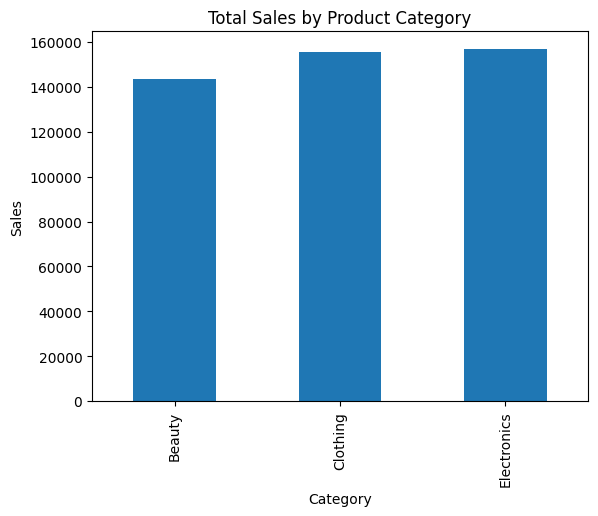

In [32]:
import matplotlib.pyplot as plt


df.groupby('Product_Category')['Total_Amount'].sum().plot(kind= 'bar')
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

Clothing and Electronics contribute the highest revenue, indicating strong customer demand in these categories.

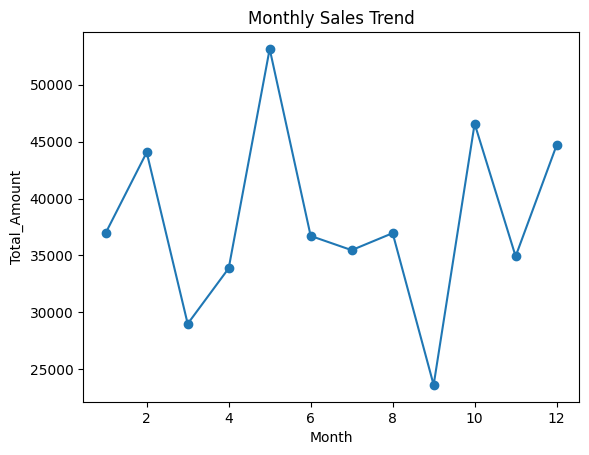

In [40]:
df['Month'] = df['Date'].dt.month

df.groupby('Month')['Total_Amount'].sum().plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel('Total_Amount')
plt.show()

Sales fluctuate across months, with a peak around Month 5 and a significant drop around Month 9. This indicates seasonal demand patterns.

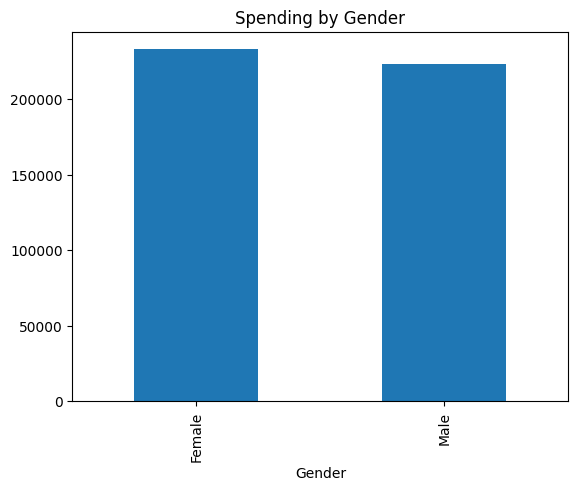

In [35]:
df.groupby('Gender')['Total_Amount'].sum().plot(kind='bar')
plt.title("Spending by Gender")
plt.show()

Female customers spend slightly more than male customers, indicating higher purchasing power or engagement

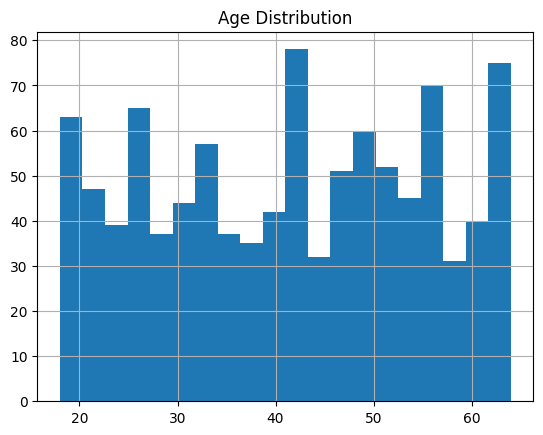

In [36]:
df['Age'].hist(bins=20)
plt.title("Age Distribution")
plt.show()

Most customers fall between ages 25–50, showing that middle-aged customers are the primary buyers.

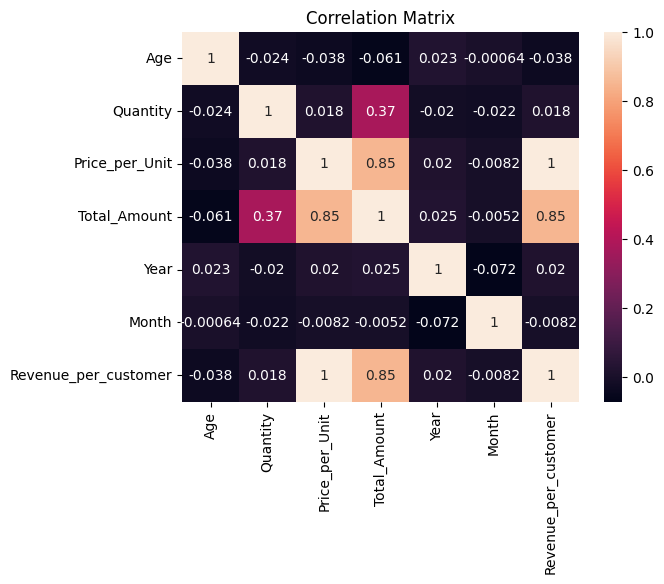

In [37]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

Strong correlation between Price_per_Unit and Total_Amount (0.85)
Moderate correlation between Quantity and Total_Amount (0.37)
Age has very low correlation with spending
Total revenue is mainly driven by price and quantity, not customer age

Gender            Female   Male
Product_Category               
Beauty             74830  68685
Clothing           81275  74305
Electronics        76735  80170


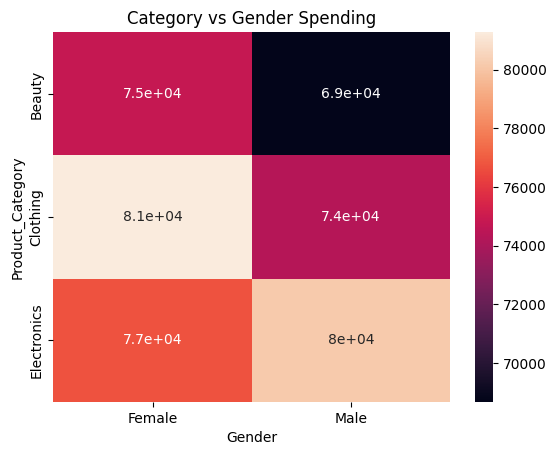

In [38]:
pivot = df.pivot_table(
    values='Total_Amount',
    index='Product_Category',
    columns='Gender',
    aggfunc='sum'
)

print(pivot)
sns.heatmap(pivot, annot=True)
plt.title("Category vs Gender Spending")
plt.show()

Females spend more on Clothing and Beauty
Males spend more on Electronics

<Axes: xlabel='Month'>

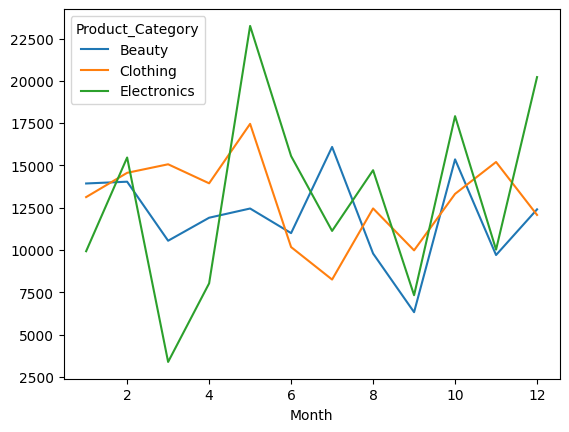

In [44]:
pivot = df.pivot_table(values='Total_Amount',
                       index='Month',
                       columns='Product_Category',
                       aggfunc='sum')

pivot.plot()



Data Quality Report:

 Total Records: 1000
 Missing Values: None
 Duplicate Records: None
 Data Types: Corrected (Date converted to datetime)
 Outliers: None detected using IQR method
 Transformations:
  • Dropped Transaction ID
  • Extracted Month from Date

This project analyzes retail sales data to identify trends, customer behavior, and key business insights. 
The goal is to improve decision-making and increase revenue.

Increase stock before high-sales months (like Month 5)
Run discounts during low-sales months (like Month 9)
Target female customers with personalized offers
Promote electronics to male customers
Optimize pricing strategy to maximize revenue
Sales were increased in the month 5 because of increase in the purchase of electronics 
Discounts to be given in the month of march and September for Electronics 
Discounts to be given in the month of September for Beauty products

In [45]:
df.to_csv("cleaned_retail_data.csv", index=False)